### [ 주제 : CNN AutoEncoder — Linear와 성능 비교 ]

08 진단: id_02/06은 구별 신호가 있는데 **Linear AE가 놓침** (스펙트로그램을 한 줄로 펴서 구조를 버림).
→ 2D 구조를 살리는 **CNN AutoEncoder**로 개선 시도.

- CNN은 입출력이 Linear와 똑같이 펴진 벡터라 **기존 파이프라인 드롭인**(모델만 교체)
- CNN 파라미터 46,529 vs Linear 20,599,424 (약 440배 작음)
- 통제: 기계별로 Linear·CNN 둘 다 학습 → AUC 비교

In [1]:
## [0] 준비
import sys
sys.path.insert(0, '..')
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
from src import config, data, train, evaluate
from src.model import AutoEncoder, CNNAutoEncoder, CNNBottleneckAE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('학습 장치 :', DEVICE)

학습 장치 : cuda


In [2]:
## [1] 기계별 Linear·CNN·CNN-BN 학습 → AUC (4기계 × 3모델 = 12회, ~15~20분)
# TODO:
MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
rows = {}
for m in MACHINES:
    trainNP, teN, teA = data.load_split_normalize(seed=42, machine=m)
    res = {}
    for name, ModelCls in [('Linear', AutoEncoder),
                           ('CNN', CNNAutoEncoder),
                           ('CNN-BN', CNNBottleneckAE)]:
        torch.manual_seed(42)
        model = ModelCls().to(DEVICE)
        model, _ = train.train_model(model, trainNP, DEVICE)
        en = evaluate.recon_errors(model, teN, DEVICE)
        ea = evaluate.recon_errors(model, teA, DEVICE)
        res[name] = evaluate.compute_auc(en, ea)
    rows[m] = res
    print(f"{m}: Linear {res['Linear']:.4f} / CNN {res['CNN']:.4f} / CNN-BN {res['CNN-BN']:.4f}")




id_00: Linear 0.9443 / CNN 0.8370 / CNN-BN 0.9677
id_02: Linear 0.7259 / CNN 0.6323 / CNN-BN 0.7195
id_04: Linear 0.5275 / CNN 0.5452 / CNN-BN 0.5673
id_06: Linear 0.4761 / CNN 0.4800 / CNN-BN 0.4638


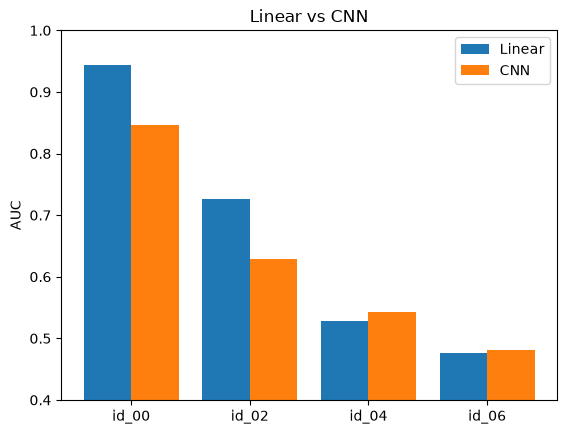

In [3]:
## [2] 기계별 Linear vs CNN vs CNN-BN 막대그래프 (나란히)
# TODO:
import matplotlib.pyplot as plt
import koreanize_matplotlib
machines = list(rows.keys())
lin = [rows[m]['Linear'] for m in machines]
cnn = [rows[m]['CNN'] for m in machines]
cnn_bn = [rows[m]['CNN-BN'] for m in machines]
xpos = np.arange(len(machines))
plt.bar(xpos-0.25, lin, width=0.25, label='Linear')
plt.bar(xpos, cnn, width=0.25, label='CNN')
plt.bar(xpos+0.25, cnn_bn, width=0.25, label='CNN-BN')
plt.xticks(xpos, machines); plt.ylim(0.4, 1.0); plt.ylabel('AUC'); plt.legend(); plt.title('Linear·CNN·CNN-BN 모델별 AUC 비교')
plt.show()



## 결과 해석

| 기계 | Linear | CNN | CNN-BN |
|------|:------:|:---:|:------:|
| id_00 | 0.9443 | 0.8370 | **0.9677** |
| id_02 | **0.7259** | 0.6323 | 0.7195 |
| id_04 | 0.5275 | 0.5452 | **0.5673** |
| id_06 | 0.4761 | **0.4800** | 0.4638 |

**관찰:**
- CNN-BN은 병목 없는 CNN보다 id_00·id_02·id_04에서 개선됐다. 특히 id_00은 Linear도 넘어 병목 가설을 강하게 지지한다.
- id_02는 Linear에 근접했지만 넘지 못했고, id_06은 오히려 낮아졌다. 병목만으로 기계별 일반화 한계까지 해결되지는 않았다.
- 실행 조건: seed=42, EPOCHS=30, LR=0.001, CUDA. CUDA 연산 특성상 기존 실행과 소수점 수준 차이가 날 수 있다.